# Support Vector Machines

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score, f1_score, recall_score

import re

In [16]:
#read in proteomics data
data = pd.read_csv('pdc_joined_all_cancer_types.txt')
data.head()

/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T/ipykernel_35363/274833952.py:2: DtypeWarning: Columns (0: alcohol_history) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('pdc_joined_all_cancer_types.txt')


,aliquot_submitter_id,A1BG,A2M,A2ML1,AAAS,AACS,AADAT,AAED1,AAGAB,AAK1,...,ZNF302,ZNF391,ZNF404,ZNF43,ZNF431,ZNF438,ZNF527,ZNF689,ZNF707,ZNF93
0,263d3f-I,1.5591,1.4396,0.0470,0.3621,0.5217,NaN,0.4883,-0.2769,0.0816,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A2-A0CM-01A,-0.2842,-0.1318,1.5785,0.0939,-0.8186,0.3095,NaN,-0.2740,0.0278,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A2-A0D0-01A,0.8159,0.7543,-1.6186,1.4300,-0.1409,NaN,-2.6694,0.0144,-0.1223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A2-A0D1-01A,1.4509,1.2298,-0.0068,1.0839,-0.5940,2.4772,NaN,0.9372,0.4364,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A2-A0D2-01A,0.0133,-0.0624,-0.4037,0.3813,-0.5412,0.7456,0.3724,-0.2081,0.0353,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [48]:
#types of cancer present
print(data['cancer_type'].unique())

<StringArray>
['breast', 'ucec', 'colorectal_pnnl', 'pancreatic']
Length: 4, dtype: str


In [8]:
#print all column names
#for col in data.columns:
    #print(col)

clinical_cols = ['case_submitter_id',
                 'sample_type',
                 'case_id',
                 'disease_type',
                 'primary_site',
                 'pdc_study_id',
                 'cancer_type',
                 'ethnicity',
                 'gender',
                 'race',
                 'vital_status',
                 'days_to_birth',
                 'days_to_death',
                 'tobacco_smoking_status',
                 'alcohol_history',
                 'years_smoked',
                 'pack_years_smoked',
                 'age_years']

In [ ]:
#preprocessing: we need scaled, labeled, imputed data
#first, lets drop everything but the "cancer_type" column, which will be the label, 
# and the protein features, which are ALL CAPS and numbers, e.g., "TP53", "BRCA1"

reduced_data = data[['cancer_type'] + [col for col in data.columns if re.match(r'^[A-Z0-9]+$', col)]]



In [20]:
reduced_data.head()
#verify that only the cancer_type column and protein features remain
#for col in reduced_data.columns:
 #   print(col)

,cancer_type,A1BG,A2M,A2ML1,AAAS,AACS,AADAT,AAED1,AAGAB,AAK1,...,ZNF302,ZNF391,ZNF404,ZNF43,ZNF431,ZNF438,ZNF527,ZNF689,ZNF707,ZNF93
0,breast,1.5591,1.4396,0.0470,0.3621,0.5217,NaN,0.4883,-0.2769,0.0816,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,breast,-0.2842,-0.1318,1.5785,0.0939,-0.8186,0.3095,NaN,-0.2740,0.0278,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,breast,0.8159,0.7543,-1.6186,1.4300,-0.1409,NaN,-2.6694,0.0144,-0.1223,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,breast,1.4509,1.2298,-0.0068,1.0839,-0.5940,2.4772,NaN,0.9372,0.4364,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,breast,0.0133,-0.0624,-0.4037,0.3813,-0.5412,0.7456,0.3724,-0.2081,0.0353,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
#now we need to scale and impute. we will use StandardScaler and fill missing values with the mean (not sure if this is the best method, but we'll try it)
scaler = StandardScaler()
#remove labels as theyre non-numeric and cant be scaled
features = reduced_data.drop(columns=['cancer_type'])
scaled_features = scaler.fit_transform(features)
#reconstruct the dataframe with scaled features
scaled_data = pd.DataFrame(scaled_features, columns=features.columns)
#fill missing values with the mean
scaled_data.fillna(scaled_data.mean(), inplace=True)
#add the labels back
scaled_data['cancer_type'] = reduced_data['cancer_type']
scaled_data.head()

/var/folders/q8/9bqx74355bg060d9qxv4bsf80000gn/T/ipykernel_35363/378509303.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  scaled_data['cancer_type'] = reduced_data['cancer_type']


,A1BG,A2M,A2ML1,AAAS,AACS,AADAT,AAED1,AAGAB,AAK1,AAMDC,...,ZNF391,ZNF404,ZNF43,ZNF431,ZNF438,ZNF527,ZNF689,ZNF707,ZNF93,cancer_type
0,2.361386,2.155739,0.432059,0.848590,1.253472,1.973730e-17,6.663561e-01,-0.768979,0.005495,-0.414769,...,1.387779e-17,8.581434e-18,-2.726864e-17,2.220446e-17,0.0,1.708035e-17,7.280151e-18,-5.163828e-17,9.738798e-18,breast
1,-0.421912,-0.100090,1.701384,0.023141,-1.671124,4.660895e-01,-4.827057e-17,-0.762462,-0.234228,-0.064137,...,1.387779e-17,8.581434e-18,-2.726864e-17,2.220446e-17,0.0,1.708035e-17,7.280151e-18,-5.163828e-17,9.738798e-18,breast
2,1.239188,1.171954,-0.948410,4.135305,-0.192352,1.973730e-17,-2.486774e+00,-0.114389,-0.903046,-3.055552,...,1.387779e-17,8.581434e-18,-2.726864e-17,2.220446e-17,0.0,1.708035e-17,7.280151e-18,-5.163828e-17,9.738798e-18,breast
3,2.198009,1.854559,0.387469,3.070100,-1.181036,3.744399e+00,-4.827057e-17,1.959265,1.586418,-3.150298,...,1.387779e-17,8.581434e-18,-2.726864e-17,2.220446e-17,0.0,1.708035e-17,7.280151e-18,-5.163828e-17,9.738798e-18,breast
4,0.027299,-0.000463,0.058513,0.907682,-1.065824,1.125623e+00,5.506238e-01,-0.614376,-0.200809,-0.743603,...,1.387779e-17,8.581434e-18,-2.726864e-17,2.220446e-17,0.0,1.708035e-17,7.280151e-18,-5.163828e-17,9.738798e-18,breast


In [23]:
#now we can produce the train/test split
train_data = scaled_data.sample(frac=0.7, random_state=42)
test_data = scaled_data.drop(train_data.index)

#separate features and labels
train_unlabeled = train_data.drop(columns=['cancer_type'])
train_labels = train_data['cancer_type']
test_unlabeled = test_data.drop(columns=['cancer_type'])
test_labels = test_data['cancer_type']

In [37]:
test_unlabeled.head()


,A1BG,A2M,A2ML1,AAAS,AACS,AADAT,AAED1,AAGAB,AAK1,AAMDC,...,ZNF302,ZNF391,ZNF404,ZNF43,ZNF431,ZNF438,ZNF527,ZNF689,ZNF707,ZNF93
1,-0.421912,-0.100090,1.701384,0.023141,-1.671124,4.660895e-01,-4.827057e-17,-0.762462,-0.234228,-0.064137,...,5.111818e-17,1.387779e-17,8.581434e-18,-2.726864e-17,2.220446e-17,0.0,1.708035e-17,7.280151e-18,-5.163828e-17,9.738798e-18
4,0.027299,-0.000463,0.058513,0.907682,-1.065824,1.125623e+00,5.506238e-01,-0.614376,-0.200809,-0.743603,...,5.111818e-17,1.387779e-17,8.581434e-18,-2.726864e-17,2.220446e-17,0.0,1.708035e-17,7.280151e-18,-5.163828e-17,9.738798e-18
13,0.037416,-0.799205,0.184078,0.001597,-1.079789,1.973730e-17,-4.827057e-17,-1.223349,0.672085,0.048703,...,5.111818e-17,1.387779e-17,8.581434e-18,-2.726864e-17,2.220446e-17,0.0,1.708035e-17,7.280151e-18,-5.163828e-17,9.738798e-18
14,1.012997,-0.221395,0.304256,0.163178,0.129282,-5.449129e-01,5.920637e-01,-0.463594,0.432808,0.682577,...,5.111818e-17,1.387779e-17,8.581434e-18,-2.726864e-17,2.220446e-17,0.0,1.708035e-17,7.280151e-18,-5.163828e-17,9.738798e-18
20,2.348551,2.269578,0.467118,1.541696,0.409893,1.713169e+00,1.566352e+00,0.967156,2.025316,-2.059506,...,5.111818e-17,1.387779e-17,8.581434e-18,-2.726864e-17,2.220446e-17,0.0,1.708035e-17,7.280151e-18,-5.163828e-17,9.738798e-18


In [46]:
#train the svm model
#test a few different kernel methods
svm_model_rbf = SVC(kernel='rbf', C=10)
svm_model_rbf.fit(train_unlabeled, train_labels)
#predict on the test set
test_predictions = svm_model_rbf.predict(test_unlabeled)
#evaluate the model
accuracy = accuracy_score(test_labels, test_predictions)
print(f"rbf accuracy: {accuracy}")

svm_model_linear = SVC(kernel='linear', C=10)
svm_model_linear.fit(train_unlabeled, train_labels)
test_predictions = svm_model_linear.predict(test_unlabeled)
accuracy = accuracy_score(test_labels, test_predictions)
print(f"linear accuracy: {accuracy}")

svm_model_poly = SVC(kernel='poly', C=10)
svm_model_poly.fit(train_unlabeled, train_labels)
test_predictions = svm_model_poly.predict(test_unlabeled)
accuracy = accuracy_score(test_labels, test_predictions)
print(f"poly accuracy: {accuracy}")

rbf accuracy: 0.9852216748768473
linear accuracy: 0.9655172413793104
poly accuracy: 0.6847290640394089


In [41]:
#try different costs for each kernel, log the results in dicts
rbf = {}
poly = {}
linear = {}

for C in [0.1, 1, 10, 100]:
    rbf[C] = None
    poly[C] = None
    linear[C] = None
    svm_rbf = SVC(C=C, kernel='rbf')
    svm_rbf.fit(train_unlabeled, train_labels)
    rbf_acc = accuracy_score(test_labels, svm_rbf.predict(test_unlabeled))

    svm_poly = SVC(C=C, kernel='poly')
    svm_poly.fit(train_unlabeled, train_labels)
    poly_acc = accuracy_score(test_labels, svm_poly.predict(test_unlabeled))

    svm_linear = SVC(C=C, kernel='linear')
    svm_linear.fit(train_unlabeled, train_labels)
    linear_acc = accuracy_score(test_labels, svm_linear.predict(test_unlabeled))

    rbf[C] = rbf_acc
    poly[C] = poly_acc
    linear[C] = linear_acc

print("RBF:", rbf)
print("Poly:", poly)
print("Linear:", linear)

RBF: {0.1: 0.47783251231527096, 1: 0.9753694581280788, 10: 0.9852216748768473, 100: 0.9852216748768473}
Poly: {0.1: 0.3793103448275862, 1: 0.4827586206896552, 10: 0.6847290640394089, 100: 0.7339901477832512}
Linear: {0.1: 0.9655172413793104, 1: 0.9655172413793104, 10: 0.9655172413793104, 100: 0.9655172413793104}


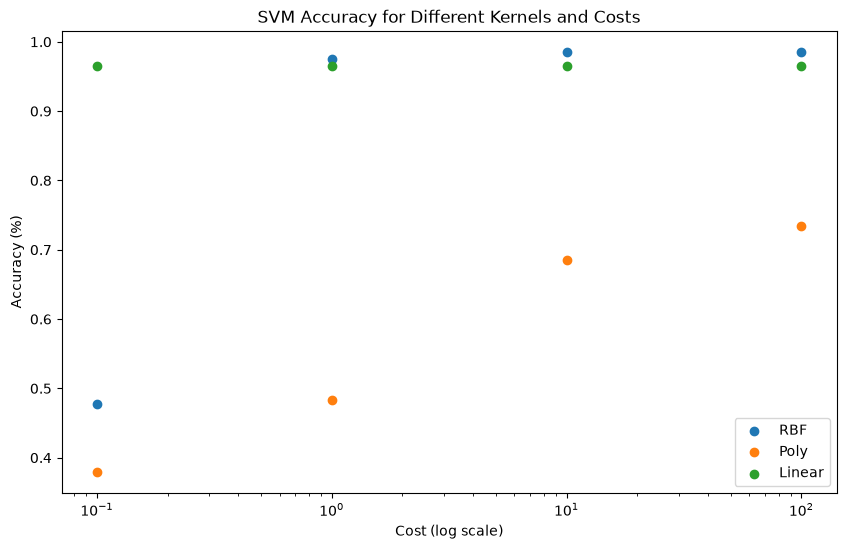

In [45]:
#plot costs in scatter plot with 3 series, 1 for each kernel type
#use a log scale for x since we have expontential cost intervals
plt.figure(figsize=(10, 6))
plt.scatter(rbf.keys(), rbf.values(), label='RBF')
plt.scatter(poly.keys(), poly.values(), label='Poly')
plt.scatter(linear.keys(), linear.values(), label='Linear')
plt.xscale('log')
plt.xlabel('Cost (log scale)')
plt.ylabel('Accuracy (%)')
plt.title('SVM Accuracy for Different Kernels and Costs')
plt.legend()
plt.show()

The linear model is very stable despite changing costs; this suggests there is a clear linear decision boundary. The poly kernel is very sensitive to cost, underfitting badly, and topping out still far below the other models. The RBF kernel performs poorly at low cost, but ultimatlely captures more than the linear kernel, suggesting there is some non-linearity that can be captured by the RBF. 


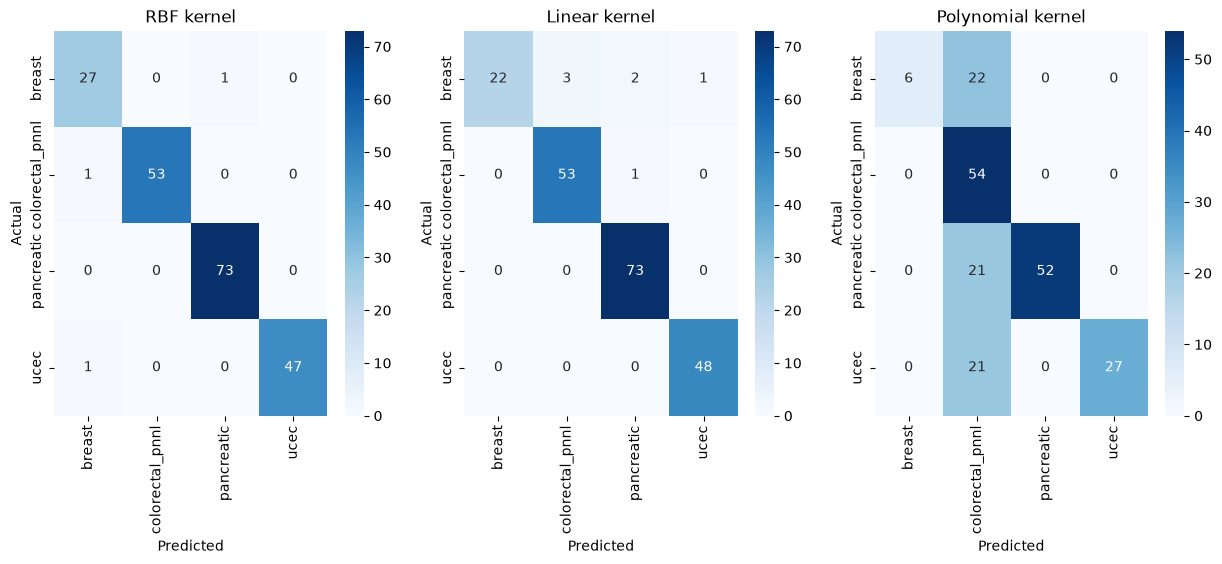

In [47]:
#confusion matrix for each kernel
conf_matrix_rbf = confusion_matrix(test_labels, svm_model_rbf.predict(test_unlabeled))
conf_matrix_linear = confusion_matrix(test_labels, svm_model_linear.predict(test_unlabeled))
conf_matrix_poly = confusion_matrix(test_labels, svm_model_poly.predict(test_unlabeled))

#apply labels to confusion matrix
conf_matrix_rbf = pd.DataFrame(conf_matrix_rbf, index=svm_model_rbf.classes_, columns=svm_model_rbf.classes_)
conf_matrix_linear = pd.DataFrame(conf_matrix_linear, index=svm_model_linear.classes_, columns=svm_model_linear.classes_)
conf_matrix_poly = pd.DataFrame(conf_matrix_poly, index=svm_model_poly.classes_, columns=svm_model_poly.classes_)

#heatmap
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
sns.heatmap(conf_matrix_rbf, annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_xlabel('Predicted')
ax[0].set_ylabel('Actual')
ax[0].set_title('RBF kernel')
sns.heatmap(conf_matrix_linear, annot=True, fmt='d', cmap='Blues', ax=ax[1])
ax[1].set_xlabel('Predicted')
ax[1].set_ylabel('Actual')
ax[1].set_title('Linear kernel')
sns.heatmap(conf_matrix_poly, annot=True, fmt='d', cmap='Blues', ax=ax[2])
ax[2].set_xlabel('Predicted')
ax[2].set_ylabel('Actual')
ax[2].set_title('Polynomial kernel')

plt.show()

In [ ]:
#interpretability - can we tell what features contributed to the model the most?
#since the linear model performed so well, the feature weights and boundary points might tell us something
weights = svm_model_linear.coef_[0]
importance = pd.DataFrame({'feature': train_unlabeled.columns,'weight': weights, 'abs_weight': np.abs(weights)}).sort_values('abs_weight', ascending=False)
print(importance.head(10))


     feature    weight  abs_weight
1982  CRYBG1 -0.010313    0.010313
9885   VCAM1 -0.008583    0.008583
7450    RETN -0.008257    0.008257
6945   PROM1 -0.007319    0.007319
8775    SUB1 -0.006314    0.006314
666    ARMT1 -0.006297    0.006297
2929   FABP6  0.006165    0.006165
1903    CPB1 -0.006139    0.006139
2623    EGFR -0.005981    0.005981
1697   CLIC6 -0.005962    0.005962
